In [1]:
import  sys
import numpy as np
from datasets import load_dataset, DatasetDict, load_metric
from transformers import AutoModelForImageClassification, AutoImageProcessor, Trainer, TrainingArguments, EarlyStoppingCallback

c:\Users\wolfg\OneDrive\Documents\CivitAI\Project Work\autoimagerater\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Notebook Purpose
<b> This is notebook number 3c </b>

To give code guidance on training ResNet models used in MixtureModel

### Notebook Order
1. getData
2. downloadData
3. trainResNetModel | trainPromptTransformerClassifier | trainViTClassifier
4. localMixtureEval

In [2]:
dataset_path = '../data/training_data/'

dataset = load_dataset('imagefolder', data_dir=dataset_path, split = "train", drop_labels = False)

In [3]:
# Split the dataset into train and test sets
splits = dataset.train_test_split(test_size=0.1, seed=42)
dataset = DatasetDict({
    'train': splits['train'],
    'test': splits['test']
})

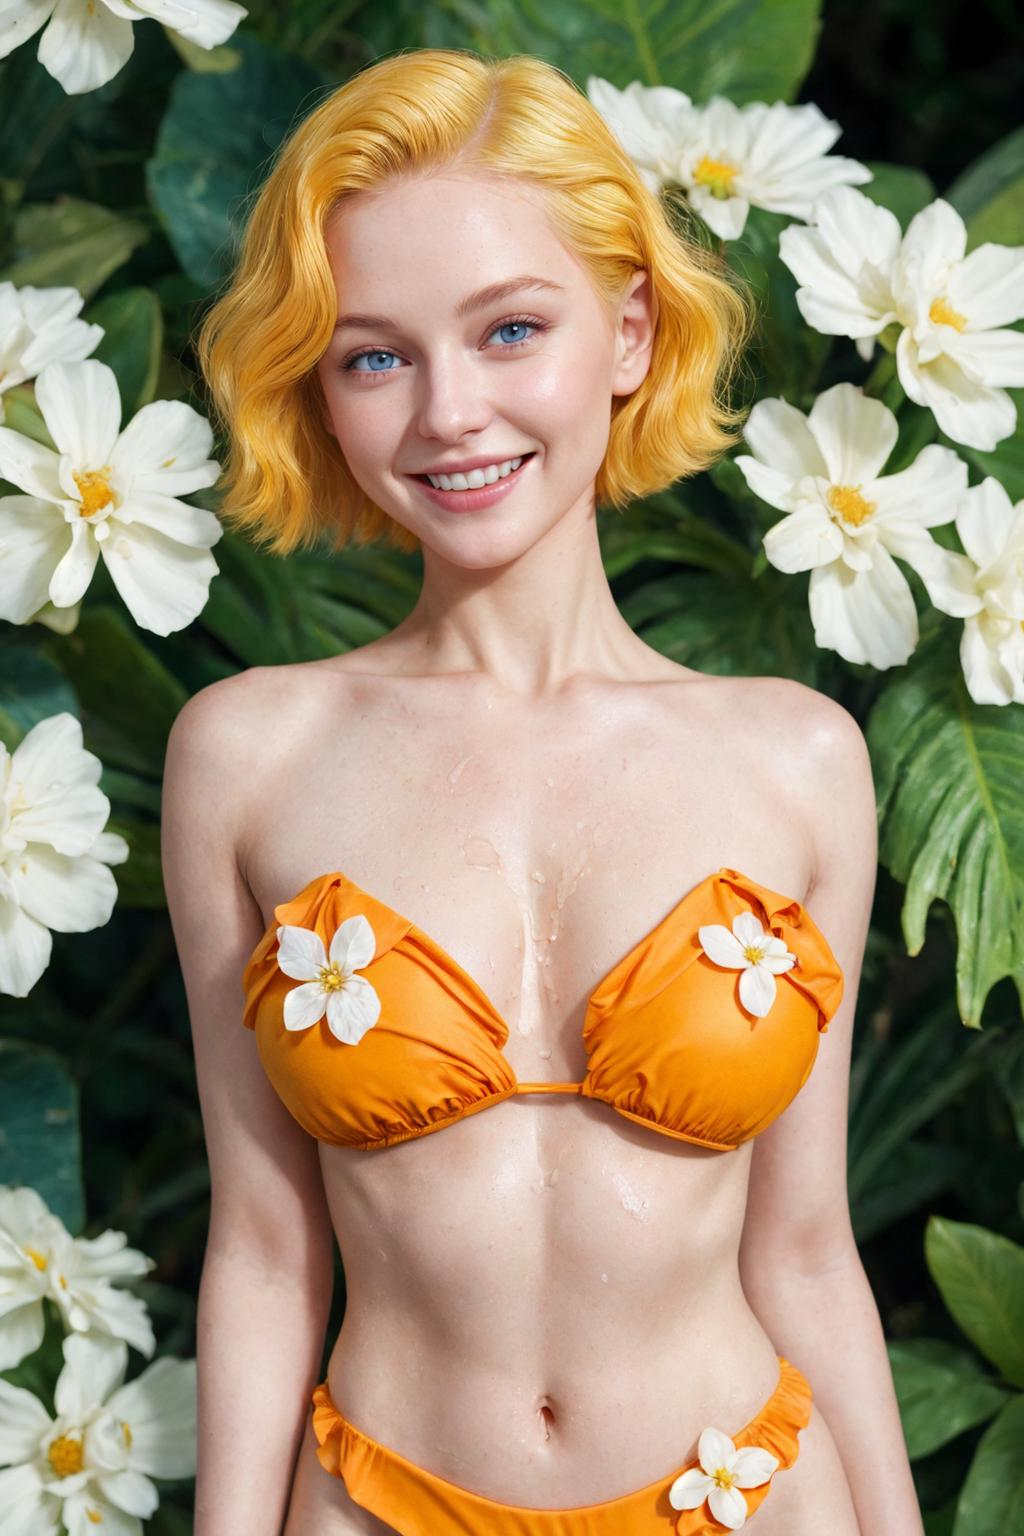

In [4]:
dataset['train'][10]['image']

In [5]:
len(dataset['train']), len(dataset['test'])

(22367, 2486)

In [6]:
labels = dataset['train'].features['label'].names

load the pretrained model for finetuning

In [7]:
# model_name = 'biet'
# model_checkpoint = 'microsoft/beit-base-patch16-224' #biet
#91.46s

# model_checkpoint = 'microsoft/swin-base-patch4-window7-224' #
# model_name = 'swin' #: 1:31:00

# model_checkpoint = 'facebook/convnext-base-224-22k-1k' #ConvNext
# model_name = 'convnext' #1:07:31

# model_checkpoint = 'google/vit-base-patch16-224'
# model_name = 'base-vit' #  train_runtime            =    0:47:33.05

# ## Larger Models:
model_name = 'biet-large-patch16-384'
model_checkpoint = 'microsoft/beit-large-patch16-384'

image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor 

c:\Users\wolfg\OneDrive\Documents\CivitAI\Project Work\autoimagerater\venv\Lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\wolfg\.cache\huggingface\hub\models--microsoft--beit-large-patch16-384. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


BeitImageProcessor {
  "_valid_processor_keys": [
    "images",
    "segmentation_maps",
    "do_resize",
    "size",
    "resample",
    "do_center_crop",
    "crop_size",
    "do_rescale",
    "rescale_factor",
    "do_normalize",
    "image_mean",
    "image_std",
    "do_reduce_labels",
    "return_tensors",
    "data_format",
    "input_data_format"
  ],
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": false,
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "BeitImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 384,
    "width": 384
  }
}

In [8]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
if "height" in image_processor.size:
    size = (image_processor.size["height"], image_processor.size["width"])
    crop_size = size
    max_size = None
elif "shortest_edge" in image_processor.size:
    size = image_processor.size["shortest_edge"]
    crop_size = (size, size)
    max_size = image_processor.size.get("longest_edge")

train_transforms = Compose(
        [
            RandomResizedCrop(crop_size),
            RandomHorizontalFlip(),
            ToTensor(),
            normalize,
        ]
    )

val_transforms = Compose(
        [
            Resize(size),
            CenterCrop(crop_size),
            ToTensor(),
            normalize,
        ]
    )

def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in example_batch["image"]
    ]
    return example_batch

def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

## prepare dataset

In [9]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label


In [10]:
train_ds = splits['train']
val_ds = splits['test']

In [11]:
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [12]:
train_ds[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=450x658>,
 'label': 4,
 'pixel_values': tensor([[[ 0.3412,  0.3412,  0.3412,  ...,  0.3412,  0.3412,  0.3412],
          [ 0.3412,  0.3412,  0.3412,  ...,  0.3412,  0.3412,  0.3412],
          [ 0.3412,  0.3412,  0.3412,  ...,  0.3412,  0.3412,  0.3412],
          ...,
          [ 0.1529,  0.1451,  0.1373,  ..., -0.7255, -0.7098, -0.7255],
          [ 0.1529,  0.1451,  0.1373,  ..., -0.7333, -0.7176, -0.7098],
          [ 0.1529,  0.1451,  0.1373,  ..., -0.7412, -0.7255, -0.7020]],
 
         [[ 0.3412,  0.3412,  0.3412,  ...,  0.3412,  0.3412,  0.3412],
          [ 0.3412,  0.3412,  0.3412,  ...,  0.3412,  0.3412,  0.3412],
          [ 0.3412,  0.3412,  0.3412,  ...,  0.3412,  0.3412,  0.3412],
          ...,
          [-0.0118, -0.0196, -0.0275,  ..., -0.7490, -0.7333, -0.7490],
          [-0.0118, -0.0196, -0.0275,  ..., -0.7569, -0.7412, -0.7333],
          [-0.0118, -0.0196, -0.0275,  ..., -0.7647, -0.7490, -0.7255]]

## Load Model

In [13]:
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint, 
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes = True, # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)


Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/beit-large-patch16-384 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([5, 1024]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## prepare trainer

In [14]:
metric = load_metric("accuracy")
def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

C:\Users\wolfg\AppData\Local\Temp\ipykernel_38204\3595139444.py:1: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  metric = load_metric("accuracy")
c:\Users\wolfg\OneDrive\Documents\CivitAI\Project Work\autoimagerater\venv\Lib\site-packages\datasets\load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.1/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


In [15]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [16]:

training_args = TrainingArguments(
  output_dir=f"../models/july_24/{model_name}_finetuned/",
  per_device_train_batch_size=32,
  evaluation_strategy="epoch",
  save_strategy="epoch",
  num_train_epochs=50,
  fp16=True,
  logging_steps=50,
  learning_rate=5e-5,
  gradient_accumulation_steps=4,
  save_total_limit=2,
  remove_unused_columns=False,
  push_to_hub=False,
  load_best_model_at_end=True,
  metric_for_best_model='accuracy',  # Use accuracy for selecting the best model
)


c:\Users\wolfg\OneDrive\Documents\CivitAI\Project Work\autoimagerater\venv\Lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks= [EarlyStoppingCallback(early_stopping_patience=5)]
)

## Train and save model

In [18]:
train_results = trainer.train()

  0%|          | 0/8700 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 652.00 MiB. GPU 

In [ ]:
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

***** train metrics *****
  epoch                    =       13.9971
  total_flos               = 22599789407GF
  train_loss               =         0.527
  train_runtime            =    0:47:33.05
  train_samples_per_second =       391.984
  train_steps_per_second   =         3.049
